# Fine-tuning BERT in Google Colab

Этот ноутбук показывает, как дообучать BERT под разные типы задач на одной GPU в Google Colab.

Мы разберём четыре примера:
1. **Классификация текста**: `glue/sst2`
2. **Sequence labeling / NER**: `conll2003`
3. **Sentence pair classification**: `glue/mrpc`
4. **Extractive QA**: `squad`

В качестве домашнего задания можно взять:
- **Классификация текста**: `imdb` или `ag_news`
- **NER**: `wnut_17` или `wikiann`
- **Question Answering**: `SQuAD` или `BoolQ`

Необходимо обучить одну модель и написать небольшой отчет:
- сколько данных использовали,
- сколько времени заняло обучение,
- какое качество получилось,
- какие гиперпараметры проверяли

In [1]:
# @title 0. Установка библиотек
!pip -q install -U transformers datasets evaluate accelerate seqeval scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 17.4 MB/s eta 0:00:00


In [3]:
# @title 1. Импорты и базовые настройки
import os
import random
import numpy as np
import torch

from datasets import load_dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    DataCollatorWithPadding,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
GPU: Tesla T4


## Часть A. Sequence classification: SST-2

Это бинарная классификация тональности:
- `0` — negative
- `1` — positive

Мы используем `bert-base-uncased` и голову `AutoModelForSequenceClassification`.

In [4]:
# @title 2. Загружаем датасет SST-2 и смотрим примеры
dataset_name = "glue"
dataset_config = "sst2"

raw_datasets = load_dataset(dataset_name, dataset_config)
print(raw_datasets)

for split in ["train", "validation"]:
    print(f"\n--- {split} examples ---")
    for i in range(3):
        ex = raw_datasets[split][i]
        print(f"[{i}] sentence = {ex['sentence']}")
        print(f"    label    = {ex['label']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

--- train examples ---
[0] sentence = hide new secretions from the parental units 
    label    = 0
[1] sentence = contains no wit , only labored gags 
    label    = 0
[2] sentence = that loves its characters and communicates something rather beautiful about human nature 
    label    = 1

--- validation examples ---
[0] sentence = it 's a charming and often affecting journey . 
    label    = 1
[1] sentence = unflinchingly bleak and desperate 
    label    = 0
[2] sentence = allows us to hope that nolan is poised to embark a major career as a commercial yet inventive filmmaker . 
    label    = 1


In [5]:
# @title 3. Токенизатор и препроцессинг
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def preprocess_sst2(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = raw_datasets.map(preprocess_sst2, batched=True)
print(tokenized_datasets)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})


In [6]:
# @title 4. Загружаем BERT c classification head и печатаем модель
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

print(model)
print("\nClassifier head:")
print(model.classifier)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

class BertPooler(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.activation = nn.Tanh()

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        # We "pool" the model by simply taking the hidden state corresponding
        # to the first token.
        first_token_tensor = hidden_states[:, 0]
        pooled_output = self.dense(first_token_tensor)
        pooled_output = self.activation(pooled_output)
        return pooled_output

In [7]:
# @title 5. Метрики
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics_sst2(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="binary")["f1"]
    return {"accuracy": acc, "f1": f1}

In [8]:
# @title 6. Fine-tuning on SST-2
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataset = tokenized_datasets["train"].select(range(100))
eval_dataset = tokenized_datasets["validation"].select(range(100))

# Хотим примерно 10 валидаций за эпоху
steps_per_epoch = len(train_dataset) // 16
#eval_steps = max(1, steps_per_epoch // 10)
eval_steps = 5
print("Approx. steps per epoch:", steps_per_epoch)
print("Validation every", eval_steps, "steps")

training_args = TrainingArguments(
    output_dir="./bert-sst2",
    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=eval_steps,
    logging_strategy="steps",
    #logging_steps=max(1, eval_steps // 2),
    logging_steps = 1,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_sst2,
)

trainer.train()


Approx. steps per epoch: 6
Validation every 5 steps
{'loss': '0.6886', 'grad_norm': '4.622', 'learning_rate': '2e-05', 'epoch': '0.1429'}
{'loss': '0.6898', 'grad_norm': '3.038', 'learning_rate': '1.857e-05', 'epoch': '0.2857'}
{'loss': '0.6675', 'grad_norm': '2.457', 'learning_rate': '1.714e-05', 'epoch': '0.4286'}
{'loss': '0.7249', 'grad_norm': '5.2', 'learning_rate': '1.571e-05', 'epoch': '0.5714'}
{'loss': '0.7421', 'grad_norm': '3.998', 'learning_rate': '1.429e-05', 'epoch': '0.7143'}
{'eval_loss': '0.6831', 'eval_accuracy': '0.54', 'eval_f1': '0.6167', 'eval_runtime': '0.3662', 'eval_samples_per_second': '273.1', 'eval_steps_per_second': '10.92', 'epoch': '0.7143'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6977', 'grad_norm': '5.362', 'learning_rate': '1.286e-05', 'epoch': '0.8571'}
{'loss': '0.679', 'grad_norm': '4.237', 'learning_rate': '1.143e-05', 'epoch': '1'}
{'loss': '0.691', 'grad_norm': '5.87', 'learning_rate': '1e-05', 'epoch': '1.143'}
{'loss': '0.6525', 'grad_norm': '2.125', 'learning_rate': '8.571e-06', 'epoch': '1.286'}
{'loss': '0.6365', 'grad_norm': '2.096', 'learning_rate': '7.143e-06', 'epoch': '1.429'}
{'eval_loss': '0.6783', 'eval_accuracy': '0.58', 'eval_f1': '0.6818', 'eval_runtime': '0.4318', 'eval_samples_per_second': '231.6', 'eval_steps_per_second': '9.263', 'epoch': '1.429'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6967', 'grad_norm': '3.092', 'learning_rate': '5.714e-06', 'epoch': '1.571'}
{'loss': '0.6786', 'grad_norm': '3.471', 'learning_rate': '4.286e-06', 'epoch': '1.714'}
{'loss': '0.6486', 'grad_norm': '2.105', 'learning_rate': '2.857e-06', 'epoch': '1.857'}
{'loss': '0.6704', 'grad_norm': '5.076', 'learning_rate': '1.429e-06', 'epoch': '2'}
{'eval_loss': '0.6766', 'eval_accuracy': '0.6', 'eval_f1': '0.6923', 'eval_runtime': '0.2934', 'eval_samples_per_second': '340.9', 'eval_steps_per_second': '13.63', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '34.38', 'train_samples_per_second': '5.817', 'train_steps_per_second': '0.407', 'train_loss': '0.6831', 'epoch': '2'}


TrainOutput(global_step=14, training_loss=0.6831432964120593, metrics={'train_runtime': 34.3803, 'train_samples_per_second': 5.817, 'train_steps_per_second': 0.407, 'train_loss': 0.6831432964120593, 'epoch': 2.0})

In [9]:
# @title 7. Оценка на validation
sst2_metrics = trainer.evaluate()
sst2_metrics

{'eval_loss': '0.6766', 'eval_accuracy': '0.6', 'eval_f1': '0.6923', 'eval_runtime': '0.3426', 'eval_samples_per_second': '291.9', 'eval_steps_per_second': '11.68', 'epoch': '2'}


{'eval_loss': 0.6765656471252441,
 'eval_accuracy': 0.6,
 'eval_f1': 0.6923076923076923,
 'eval_runtime': 0.3426,
 'eval_samples_per_second': 291.917,
 'eval_steps_per_second': 11.677,
 'epoch': 2.0}

=== Train logs ===


,step,epoch,loss,grad_norm,learning_rate
4,5,0.714286,0.742097,3.998218,0.000014
6,6,0.857143,0.697735,5.362038,0.000013
7,7,1.000000,0.679049,4.236638,0.000011
8,8,1.142857,0.691041,5.869887,0.000010
9,9,1.285714,0.652455,2.124974,0.000009
10,10,1.428571,0.636538,2.095564,0.000007
12,11,1.571429,0.696721,3.092092,0.000006
13,12,1.714286,0.678623,3.470540,0.000004
14,13,1.857143,0.648584,2.104848,0.000003
15,14,2.000000,0.670364,5.076386,0.000001



=== Eval logs ===


,step,epoch,eval_loss,eval_accuracy,eval_f1,eval_runtime
5,5,0.714286,0.683050,0.54,0.616667,0.3662
11,10,1.428571,0.678294,0.58,0.681818,0.4318
16,14,2.000000,0.676566,0.60,0.692308,0.2934
18,14,2.000000,0.676566,0.60,0.692308,0.3426



=== Summary logs ===


,train_runtime,train_samples_per_second,train_steps_per_second,train_loss,epoch
17,34.3803,5.817,0.407,0.683143,2.0


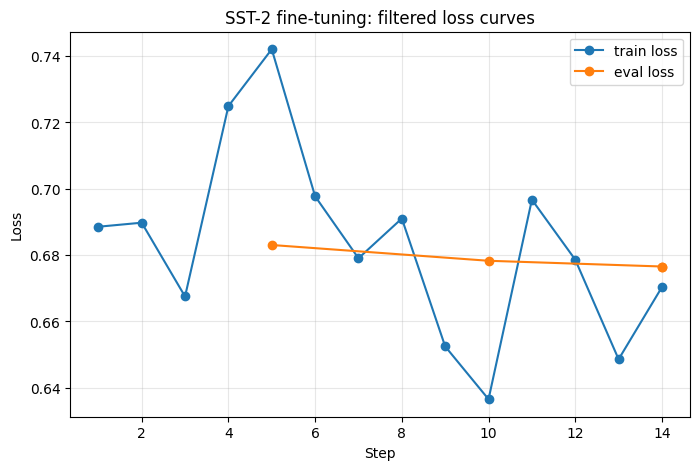

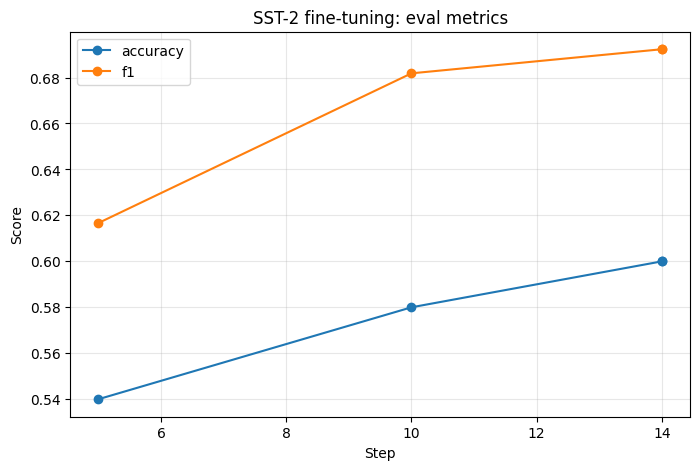

In [10]:
# @title 8. Отфильтрованные логи + графики для SST-2
import matplotlib.pyplot as plt
import pandas as pd

log_df = pd.DataFrame(trainer.state.log_history)

# Отдельно train / eval / итоговые summary-строки
train_logs = log_df.dropna(subset=["loss"]).copy() if "loss" in log_df.columns else pd.DataFrame()
eval_logs = log_df.dropna(subset=["eval_loss"]).copy() if "eval_loss" in log_df.columns else pd.DataFrame()
summary_logs = log_df.dropna(subset=["train_loss"]).copy() if "train_loss" in log_df.columns else pd.DataFrame()

print("=== Train logs ===")
if len(train_logs) > 0:
    cols = [c for c in ["step", "epoch", "loss", "grad_norm", "learning_rate"] if c in train_logs.columns]
    display(train_logs[cols].tail(10))
else:
    print("Нет train-логов")

print("\n=== Eval logs ===")
if len(eval_logs) > 0:
    cols = [c for c in ["step", "epoch", "eval_loss", "eval_accuracy", "eval_f1", "eval_runtime"] if c in eval_logs.columns]
    display(eval_logs[cols].tail(10))
else:
    print("Нет eval-логов")

print("\n=== Summary logs ===")
if len(summary_logs) > 0:
    cols = [c for c in ["train_runtime", "train_samples_per_second", "train_steps_per_second", "train_loss", "epoch"] if c in summary_logs.columns]
    display(summary_logs[cols].tail(10))
else:
    print("Нет summary-логов")

# 1. Loss curves
plt.figure(figsize=(8, 5))

if len(train_logs) > 0:
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if len(eval_logs) > 0:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="o", label="eval loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("SST-2 fine-tuning: filtered loss curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2. Eval metrics
metric_cols = [c for c in ["eval_accuracy", "eval_f1"] if c in eval_logs.columns]

if len(eval_logs) > 0 and len(metric_cols) > 0:
    plt.figure(figsize=(8, 5))
    for col in metric_cols:
        plt.plot(eval_logs["step"], eval_logs[col], marker="o", label=col.replace("eval_", ""))
    plt.xlabel("Step")
    plt.ylabel("Score")
    plt.title("SST-2 fine-tuning: eval metrics")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Нет eval-метрик для графика")

In [11]:
# @title 9. Несколько предсказаний модели
sample_texts = [
    "This movie was surprisingly touching and well-acted.",
    "I regret wasting two hours on this boring film.",
    "The plot is simple, but the characters are charming.",
]

inputs = tokenizer(sample_texts, truncation=True, padding=True, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model(**inputs)
    preds = outputs.logits.argmax(dim=-1).cpu().numpy()

for text, pred in zip(sample_texts, preds):
    print(f"TEXT: {text}")
    print(f"PRED: {id2label[int(pred)]}")
    print()

TEXT: This movie was surprisingly touching and well-acted.
PRED: POSITIVE

TEXT: I regret wasting two hours on this boring film.
PRED: POSITIVE

TEXT: The plot is simple, but the characters are charming.
PRED: POSITIVE



### Домашнее задание для той же задачи

Возьмите **один** из датасетов:
- `imdb`
- `ag_news`

Что надо поменять:
1. колонки текста и label,
2. число классов,
3. метрику (для `ag_news` лучше macro-F1 + accuracy).

Подсказка:
- `imdb` — бинарная классификация, похоже на SST-2
- `ag_news` — 4 класса




In [12]:
# @title 10. Заготовка для домашки: text classification на другом датасете
# Пример: раскомментируйте и адаптируйте под imdb или ag_news
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

hw_raw = load_dataset("imdb")

hw_raw = hw_raw.rename_column("text", "review")
hw_raw = hw_raw.rename_column("label", "labels")

print(hw_raw)
print(hw_raw["train"][0])

id2label = {0: "POSITIVE", 1: "NEGATIVE"}

def preprocess_hw(batch):
    return tokenizer(batch["review"], truncation=True, max_length=256)

hw_tok = hw_raw.map(preprocess_hw, batched=True)

num_labels = 2
hw_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels = num_labels,
    id2label = id2label
)

print(hw_model)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [14]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    return {"accuracy": acc}

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataset = hw_tok["train"].select(range(200))
eval_dataset = hw_tok["test"].select(range(200))

# Хотим примерно 10 валидаций за эпоху
steps_per_epoch = len(train_dataset) // 16
#eval_steps = max(1, steps_per_epoch // 10)
eval_steps = 5
print("Approx. steps per epoch:", steps_per_epoch)
print("Validation every", eval_steps, "steps")

training_args = TrainingArguments(
    output_dir="./bert-sst2",
    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=eval_steps,
    logging_strategy="steps",
    #logging_steps=max(1, eval_steps // 2),
    logging_steps = 1,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Approx. steps per epoch: 12
Validation every 5 steps
{'loss': '0.3128', 'grad_norm': '5.563', 'learning_rate': '2e-05', 'epoch': '0.1429'}
{'loss': '0.2481', 'grad_norm': '5.216', 'learning_rate': '1.857e-05', 'epoch': '0.2857'}
{'loss': '0.1847', 'grad_norm': '3.405', 'learning_rate': '1.714e-05', 'epoch': '0.4286'}
{'loss': '0.1496', 'grad_norm': '3.829', 'learning_rate': '1.571e-05', 'epoch': '0.5714'}
{'loss': '0.111', 'grad_norm': '2.422', 'learning_rate': '1.429e-05', 'epoch': '0.7143'}
{'eval_loss': '0.09736', 'eval_accuracy': '1', 'eval_runtime': '4.292', 'eval_samples_per_second': '46.6', 'eval_steps_per_second': '1.631', 'epoch': '0.7143'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1108', 'grad_norm': '3.173', 'learning_rate': '1.286e-05', 'epoch': '0.8571'}
{'loss': '0.08986', 'grad_norm': '3.391', 'learning_rate': '1.143e-05', 'epoch': '1'}
{'loss': '0.08251', 'grad_norm': '1.842', 'learning_rate': '1e-05', 'epoch': '1.143'}
{'loss': '0.07869', 'grad_norm': '3.134', 'learning_rate': '8.571e-06', 'epoch': '1.286'}
{'loss': '0.06049', 'grad_norm': '1.701', 'learning_rate': '7.143e-06', 'epoch': '1.429'}
{'eval_loss': '0.0563', 'eval_accuracy': '1', 'eval_runtime': '3.704', 'eval_samples_per_second': '54', 'eval_steps_per_second': '1.89', 'epoch': '1.429'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.05431', 'grad_norm': '1.19', 'learning_rate': '5.714e-06', 'epoch': '1.571'}
{'loss': '0.05159', 'grad_norm': '1.204', 'learning_rate': '4.286e-06', 'epoch': '1.714'}
{'loss': '0.04536', 'grad_norm': '0.9779', 'learning_rate': '2.857e-06', 'epoch': '1.857'}
{'loss': '0.05201', 'grad_norm': '2.257', 'learning_rate': '1.429e-06', 'epoch': '2'}
{'eval_loss': '0.04568', 'eval_accuracy': '1', 'eval_runtime': '3.75', 'eval_samples_per_second': '53.33', 'eval_steps_per_second': '1.867', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '60.92', 'train_samples_per_second': '6.566', 'train_steps_per_second': '0.23', 'train_loss': '0.1166', 'epoch': '2'}


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=14, training_loss=0.11655748156564576, metrics={'train_runtime': 60.9235, 'train_samples_per_second': 6.566, 'train_steps_per_second': 0.23, 'train_loss': 0.11655748156564576, 'epoch': 2.0})

In [15]:
metrics = trainer.evaluate()
metrics

{'eval_loss': '0.097', 'eval_accuracy': '1', 'eval_runtime': '3.821', 'eval_samples_per_second': '52.34', 'eval_steps_per_second': '1.832', 'epoch': '2'}


{'eval_loss': 0.09699741005897522,
 'eval_accuracy': 1.0,
 'eval_runtime': 3.8213,
 'eval_samples_per_second': 52.338,
 'eval_steps_per_second': 1.832,
 'epoch': 2.0}

=== Train logs ===


,step,epoch,loss,grad_norm,learning_rate
4,5,0.714286,0.111043,2.421774,0.000014
6,6,0.857143,0.110754,3.173150,0.000013
7,7,1.000000,0.089857,3.390767,0.000011
8,8,1.142857,0.082505,1.841623,0.000010
9,9,1.285714,0.078686,3.133657,0.000009
10,10,1.428571,0.060487,1.701015,0.000007
12,11,1.571429,0.054310,1.190006,0.000006
13,12,1.714286,0.051594,1.203684,0.000004
14,13,1.857143,0.045360,0.977906,0.000003
15,14,2.000000,0.052011,2.256529,0.000001



=== Eval logs ===


,step,epoch,eval_loss,eval_accuracy,eval_runtime
5,5,0.714286,0.097355,1.0,4.2920
11,10,1.428571,0.056305,1.0,3.7038
16,14,2.000000,0.045675,1.0,3.7503
18,14,2.000000,0.096997,1.0,3.8213



=== Summary logs ===


,train_runtime,train_samples_per_second,train_steps_per_second,train_loss,epoch
17,60.9235,6.566,0.23,0.116557,2.0


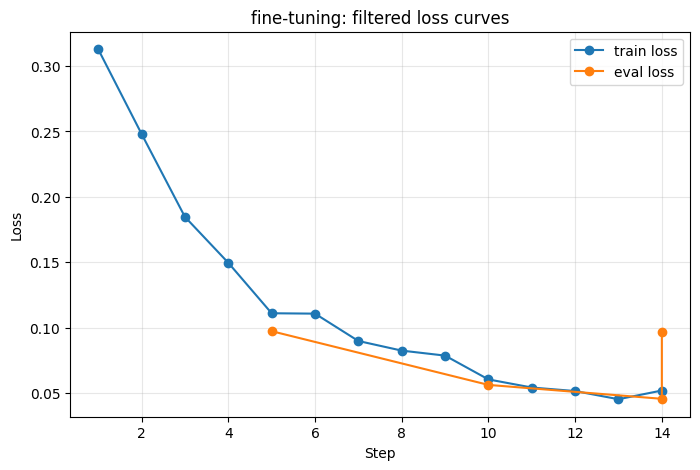

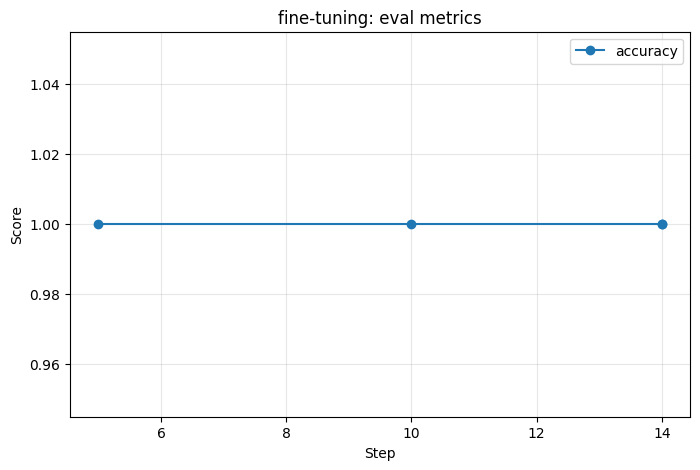

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

log_df = pd.DataFrame(trainer.state.log_history)

# Отдельно train / eval / итоговые summary-строки
train_logs = log_df.dropna(subset=["loss"]).copy() if "loss" in log_df.columns else pd.DataFrame()
eval_logs = log_df.dropna(subset=["eval_loss"]).copy() if "eval_loss" in log_df.columns else pd.DataFrame()
summary_logs = log_df.dropna(subset=["train_loss"]).copy() if "train_loss" in log_df.columns else pd.DataFrame()

print("=== Train logs ===")
if len(train_logs) > 0:
    cols = [c for c in ["step", "epoch", "loss", "grad_norm", "learning_rate"] if c in train_logs.columns]
    display(train_logs[cols].tail(10))
else:
    print("Нет train-логов")

print("\n=== Eval logs ===")
if len(eval_logs) > 0:
    cols = [c for c in ["step", "epoch", "eval_loss", "eval_accuracy", "eval_runtime"] if c in eval_logs.columns]
    display(eval_logs[cols].tail(10))
else:
    print("Нет eval-логов")

print("\n=== Summary logs ===")
if len(summary_logs) > 0:
    cols = [c for c in ["train_runtime", "train_samples_per_second", "train_steps_per_second", "train_loss", "epoch"] if c in summary_logs.columns]
    display(summary_logs[cols].tail(10))
else:
    print("Нет summary-логов")

# 1. Loss curves
plt.figure(figsize=(8, 5))

if len(train_logs) > 0:
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if len(eval_logs) > 0:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="o", label="eval loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("fine-tuning: filtered loss curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2. Eval metrics
metric_cols = [c for c in ["eval_accuracy"] if c in eval_logs.columns]

if len(eval_logs) > 0 and len(metric_cols) > 0:
    plt.figure(figsize=(8, 5))
    for col in metric_cols:
        plt.plot(eval_logs["step"], eval_logs[col], marker="o", label=col.replace("eval_", ""))
    plt.xlabel("Step")
    plt.ylabel("Score")
    plt.title("fine-tuning: eval metrics")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Нет eval-метрик для графика")

###Вывод
Я очень много эксперементировал с разными метриками, и precision/recall был, и f1, и log loss, в интернете еще несколько поискал разных. Во всех случаях не работает. Потом в запустил поиск по label что понять сколько с 1 и, и сколько с 0, из более 50000 файлов с 1 около 4500 а остальные в датасете imbd это 0, и скорее всего в выборку попадает очень маленькое число 1. Тогда увеличил выборку train до 25000, а валидационную(в случае датасета imbd тестовую) до 10000, сделал `batch_size` равным 128 чтобы больше элементов брал за раз и увеличил шаг `learning_rate` увеличил чтобы быстрее закончил, результат тотже, но затраты на время увеличились значительнее. У меня скорее всего где то ошибка в коде, поэтому в итоговой версии оставил accuracy потому что у нее график похож на гиперболу.